Nearest element index: 3251
Max energy time: 2017-08-26T03:00:00.000000000


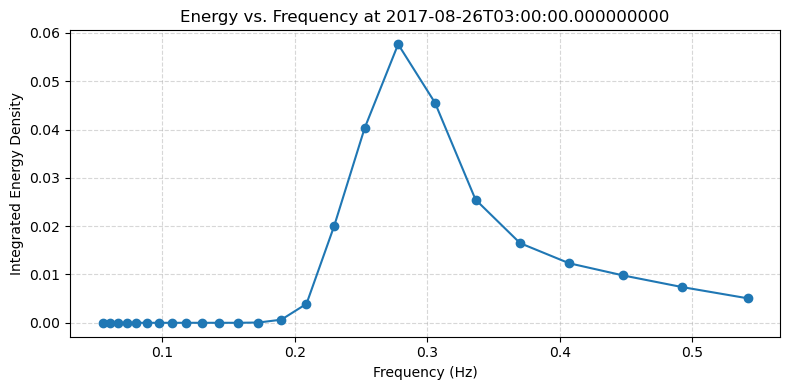

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === 1. File Path and Target Coordinate ===
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"
target_coord = (731545, 3175823)  # Example coordinate (offshore)

# === 2. Load the DFSU File ===
ds = mikeio.Dfsu(wave_energy_file)

# === 3. Find the Nearest Element ===
# Get element center coordinates (2D)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]
# Compute distances and pick the index with minimum distance
distances = np.linalg.norm(elem_coords - np.array(target_coord), axis=1)
nearest_idx = np.argmin(distances)
print(f"Nearest element index: {nearest_idx}")

# === 4. Read Spectral Energy Density Data for That Element ===
# This returns data with shape: (time, direction, frequency)
data = ds.read(items=["Energy density"], elements=[nearest_idx])
wave_energy_spectrum = data[0].values  # shape: (n_time, n_direction, n_frequency)

# === 5. Get Time, Directions, and Frequencies Arrays ===
time = np.array(ds.time)           # e.g., shape: (229,)
directions = np.array(ds.directions) # e.g., shape: (16,)
frequencies = np.array(ds.frequencies)  # e.g., shape: (25,)

# === 6. Compute Energy vs. Frequency for Each Time Step ===
# Sum over the direction axis to collapse (direction, frequency) → (frequency,)
energy_vs_freq_time = wave_energy_spectrum.sum(axis=1)  # shape: (n_time, n_frequency)

# Optionally, find the time step with maximum total energy (summed over frequency)
total_energy = energy_vs_freq_time.sum(axis=1)  # shape: (n_time,)
max_energy_idx = np.argmax(total_energy)
max_energy_time = time[max_energy_idx]
print("Max energy time:", max_energy_time)

# Extract the energy vs. frequency at the time of maximum energy
energy_vs_freq = energy_vs_freq_time[max_energy_idx, :]  # shape: (n_frequency,)

# === 7. Plot Energy vs. Frequency ===
plt.figure(figsize=(8, 4))
plt.plot(frequencies, energy_vs_freq, marker='o', linestyle='-')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Integrated Energy Density")
plt.title(f"Energy vs. Frequency at {max_energy_time}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Nearshore nearest element index: 3307
Nearshore max energy time: 2017-08-26T03:30:00.000000000
Reef flat nearest element index: 16665
Reef flat max energy time: 2017-08-26T03:00:00.000000000
Offshore nearest element index: 3251
Offshore max energy time: 2017-08-26T03:00:00.000000000


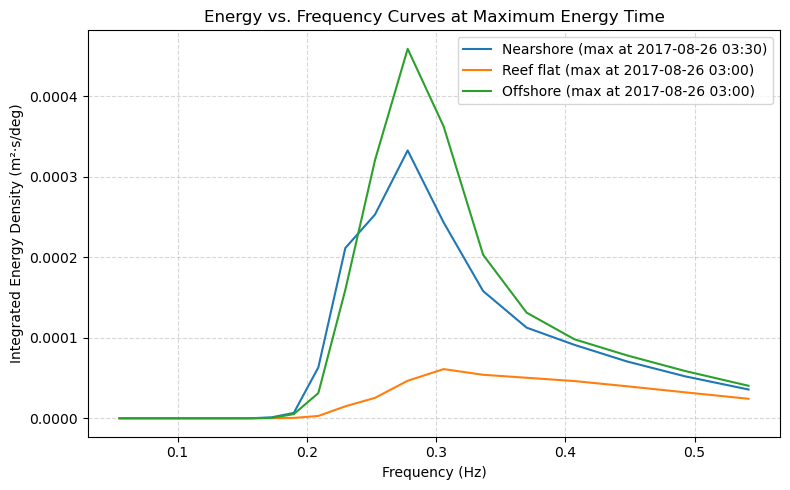

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === 1. File path and locations ===
wave_energy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\Wave_energy_west_side.dfsu"

locations = {
    "Nearshore": (730277, 3175096),
    "Reef flat": (731037, 3175492),
    "Offshore": (731545, 3175823),
}

# === 2. Load the DFSU file ===
ds = mikeio.Dfsu(wave_energy_file)

# === 3. Get geometry and spectral parameters ===
# Element center coordinates (2D)
elem_coords = np.array(ds.geometry.element_coordinates)[:, :2]

# Spectral info: directions and frequencies
directions = np.array(ds.directions)     # e.g., shape (16,)
frequencies = np.array(ds.frequencies)     # e.g., shape (25,)
# Calculate bin widths: Δθ (radians) and Δf (Hz)
dtheta_rad = np.deg2rad(np.mean(np.diff(directions)))
dfreq = np.mean(np.diff(frequencies))

# Time array (numpy.datetime64)
time_array = np.array(ds.time)

# === 4. For each location, read data and compute energy vs. frequency ===
energy_vs_freq_dict = {}     # To store the 1D energy curve (per location)
max_energy_time_dict = {}    # To store the time of maximum energy (as numpy.datetime64)

for loc_name, coord in locations.items():
    # Find the nearest element using Euclidean distance
    distances = np.linalg.norm(elem_coords - np.array(coord), axis=1)
    nearest_idx = np.argmin(distances)
    print(f"{loc_name} nearest element index: {nearest_idx}")
    
    # Read the spectral energy density for that element.
    # This returns an array with shape: (time, direction, frequency)
    data = ds.read(items=["Energy density"], elements=[nearest_idx])
    wave_energy_spectrum = data[0].values  # shape: (n_time, n_direction, n_frequency)
    
    # Integrate over directions for each time step.
    # Multiply by dtheta_rad and dfreq to get proper integration.
    energy_vs_freq_time = (wave_energy_spectrum * dtheta_rad * dfreq).sum(axis=1)  # shape: (n_time, n_frequency)
    
    # Find the time step with maximum total energy (integrated over frequency)
    total_energy = energy_vs_freq_time.sum(axis=1)  # shape: (n_time,)
    max_idx = np.argmax(total_energy)
    max_energy_time = time_array[max_idx]
    
    # Extract the energy vs. frequency curve at that time step
    energy_vs_freq = energy_vs_freq_time[max_idx, :]  # shape: (n_frequency,)
    
    energy_vs_freq_dict[loc_name] = energy_vs_freq
    max_energy_time_dict[loc_name] = max_energy_time
    print(f"{loc_name} max energy time: {max_energy_time}")

# === 5. Plot the Energy vs. Frequency Curves ===
plt.figure(figsize=(8, 5))
for loc_name, energy_curve in energy_vs_freq_dict.items():
    # Convert numpy.datetime64 to a Python datetime object using pandas
    max_time_py = pd.to_datetime(max_energy_time_dict[loc_name])
    plt.plot(frequencies, energy_curve, 
             label=f"{loc_name} (max at {max_time_py.strftime('%Y-%m-%d %H:%M')})")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Integrated Energy Density (m²·s/deg)")
plt.title("Energy vs. Frequency Curves at Maximum Energy Time")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
